# Import Library

In [1]:
!pip install Sastrawi
!pip install wordcloud
!pip install nltk
!pip install gensim -U
!pip install tensorflow
!pip install keras
!pip install xgboost

In [2]:
''' jalankan ini jika ada eror 'numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject'
. Jika berhasil dan dijalankan 2x terjadi eror, jadikan comment'''

#!pip install -qq numpy==1.26.4 gensim
#get_ipython().kernel.do_shutdown(restart=True)

" jalankan ini jika ada eror 'numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject'\n. Jika berhasil dan dijalankan 2x terjadi eror, jadikan comment"

In [3]:
import pandas as pd
pd.options.mode.chained_assignment = None

import datetime as dt
import re
import string
import csv
import requests
from io import StringIO
import tensorflow 

import numpy as np
seed=0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.utils.class_weight import compute_class_weight


import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.test.utils import common_texts
from gensim.models import Word2Vec
from tensorflow import keras
from keras.layers import Dense, Dropout, BatchNormalization, Embedding, LSTM, Activation, Input
from keras.models import Sequential
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.activations import swish, gelu

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Dataset

In [4]:
clean_df = pd.read_csv('brimo.csv')

In [5]:
clean_df.shape

(26496, 3)

In [6]:
clean_df.head()

,content,score,thumbsUpCount
0,Hasil Update hanya mengutamakan tampilan saja ...,1,7
1,setelah update terakhir selalu muncul notifika...,2,24
2,buka aplikasi Brimo tiba2 mental keluar sendir...,4,40
3,awalnya ngebug gitu tiap mau tf ke ewallet pas...,1,3
4,"Buat yg keganggu dikit2 update tak kasi tau, u...",5,2141


In [7]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content        26496 non-null  object
 1   score          26496 non-null  int64 
 2   thumbsUpCount  26496 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 621.1+ KB


# Pre Processing

In [8]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [9]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "app": "aplikasi"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [10]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [11]:
clean_df

,content,score,thumbsUpCount,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,Hasil Update hanya mengutamakan tampilan saja ...,1,7,Hasil Update hanya mengutamakan tampilan saja ...,hasil update hanya mengutamakan tampilan saja ...,hasil update hanya mengutamakan tampilan saja ...,"[hasil, update, hanya, mengutamakan, tampilan,...","[hasil, update, mengutamakan, tampilan, fungsi...",hasil update mengutamakan tampilan fungsinya s...
1,setelah update terakhir selalu muncul notifika...,2,24,setelah update terakhir selalu muncul notifika...,setelah update terakhir selalu muncul notifika...,setelah update terakhir selalu muncul notifika...,"[setelah, update, terakhir, selalu, muncul, no...","[update, muncul, notifikasi, jaringan, buruk, ...",update muncul notifikasi jaringan buruk jaring...
2,buka aplikasi Brimo tiba2 mental keluar sendir...,4,40,buka aplikasi Brimo tiba mental keluar sendiri...,buka aplikasi brimo tiba mental keluar sendiri...,buka aplikasi brimo tiba mental keluar sendiri...,"[buka, aplikasi, brimo, tiba, mental, keluar, ...","[buka, aplikasi, brimo, mental, sendiriharus, ...",buka aplikasi brimo mental sendiriharus hapus ...
3,awalnya ngebug gitu tiap mau tf ke ewallet pas...,1,3,awalnya ngebug gitu tiap mau tf ke ewallet pas...,awalnya ngebug gitu tiap mau tf ke ewallet pas...,awalnya ngebug gitu tiap mau tf ke ewallet pas...,"[awalnya, ngebug, gitu, tiap, mau, tf, ke, ewa...","[ngebug, gitu, tf, ewallet, tulisannya, akun, ...",ngebug gitu tf ewallet tulisannya akun pas cob...
4,"Buat yg keganggu dikit2 update tak kasi tau, u...",5,2141,Buat yg keganggu dikit update tak kasi tau upd...,buat yg keganggu dikit update tak kasi tau upd...,buat yang keganggu dikit update tidak kasi tah...,"[buat, yang, keganggu, dikit, update, tidak, k...","[keganggu, dikit, update, kasi, update, perbai...",keganggu dikit update kasi update perbaikan ce...
...,...,...,...,...,...,...,...,...,...
26491,Ini lagi kenapa ya setiap mau login kok ada ke...,2,0,Ini lagi kenapa ya setiap mau login kok ada ke...,ini lagi kenapa ya setiap mau login kok ada ke...,ini lagi kenapa iya setiap mau login kok ada k...,"[ini, lagi, kenapa, iya, setiap, mau, login, k...","[login, keterangan, user, terblokir, ngikutin,...",login keterangan user terblokir ngikutin ganti...
26492,"Sangat membantu, mudah di akses, tapi tetap ti...",5,2,Sangat membantu mudah di akses tapi tetap ting...,sangat membantu mudah di akses tapi tetap ting...,sangat membantu mudah di akses tapi tetap ting...,"[sangat, membantu, mudah, di, akses, tapi, tet...","[membantu, mudah, akses, tingkatkan, keamanany...",membantu mudah akses tingkatkan keamananya nas...
26493,transaksi selalu gagal padahal ada saldo,1,0,transaksi selalu gagal padahal ada saldo,transaksi selalu gagal padahal ada saldo,transaksi selalu gagal padahal ada saldo,"[transaksi, selalu, gagal, padahal, ada, saldo]","[transaksi, gagal, saldo]",transaksi gagal saldo
26494,Selalu gak bisa login dan blak screen...ini ap...,1,5,Selalu gak bisa login dan blak screenini apa m...,selalu gak bisa login dan blak screenini apa m...,selalu gak bisa login dan blak screenini apa m...,"[selalu, gak, bisa, login, dan, blak, screenin...","[login, blak, screenini, ram, hp, gbapa, buka,...",login blak screenini ram hp gbapa buka aplikas...


# Pelabelan

In [12]:
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

In [13]:
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")


In [14]:
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")


In [15]:
def sentiment_analysis_lexicon(text):
    score = 0
    for word in text:
        if (word in lexicon_positive):
            score += lexicon_positive[word]
    for word in text:
        if (word in lexicon_negative):
            score += lexicon_negative[word]

    polarity = ''
    if score > 2:
        polarity = 'positif'
    elif score  < -3:
        polarity = 'negatif'
    else:
        polarity = 'netral'

    return score, polarity


In [16]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon)
results

0          (-3, netral)
1          (-3, netral)
2        (-12, negatif)
3          (5, positif)
4        (-10, negatif)
              ...      
26491       (1, netral)
26492      (9, positif)
26493       (2, netral)
26494     (-6, negatif)
26495      (3, positif)
Name: text_stopword, Length: 26496, dtype: object

In [17]:
results = list(zip(*results))

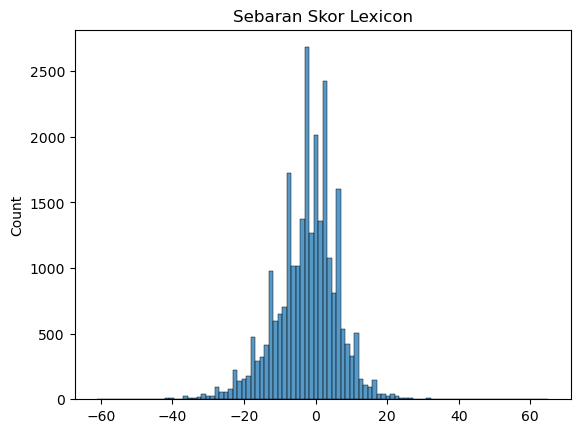

In [18]:
sns.histplot(results[0], bins=100)
plt.title("Sebaran Skor Lexicon")
plt.show()

In [19]:
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negatif    10734
netral      8378
positif     7384
Name: count, dtype: int64


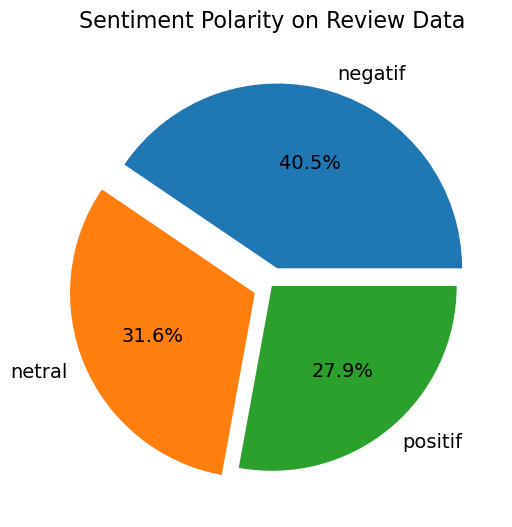

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for  count in clean_df['polarity'].value_counts()]

labels = list(clean_df['polarity'].value_counts().index)
explode = (0.1, 0.1, 0)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
plt.show()

In [21]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positif']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [22]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negatif']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

In [23]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
netral_tweets = clean_df[clean_df['polarity'] == 'netral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
netral_tweets = netral_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
netral_tweets = netral_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
netral_tweets = netral_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
netral_tweets = netral_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
netral_tweets.index += 1

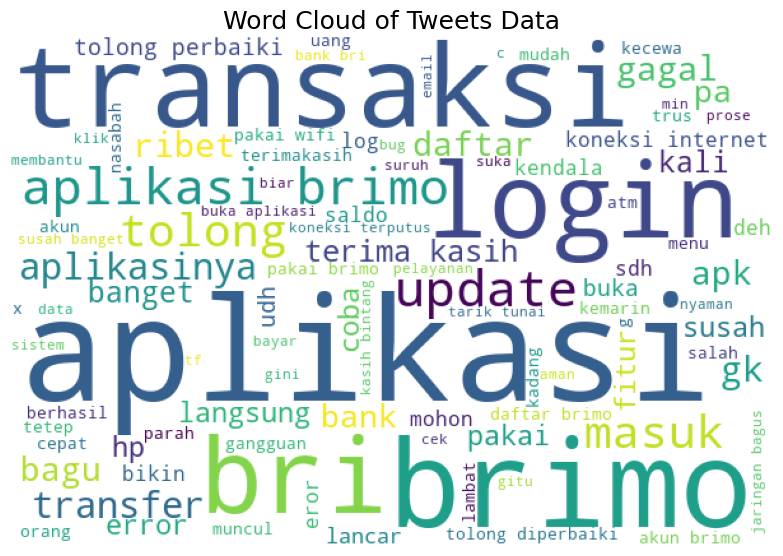

In [24]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'clean_df'.
for tweet in clean_df['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

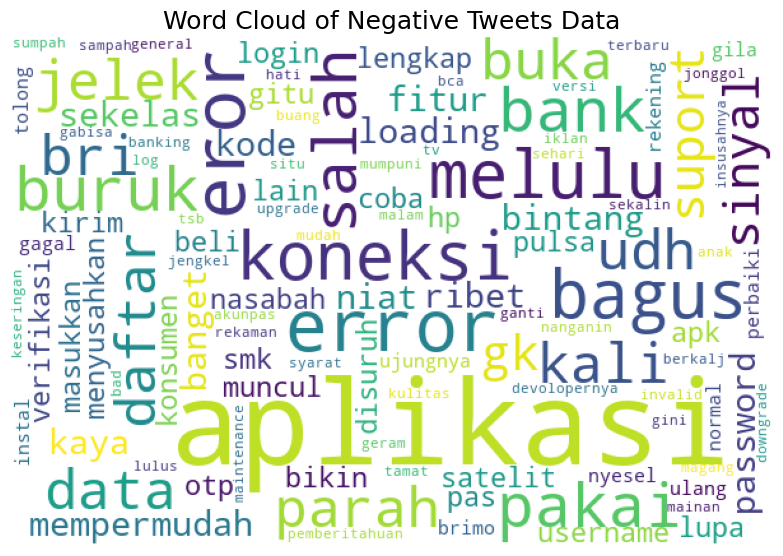

In [25]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

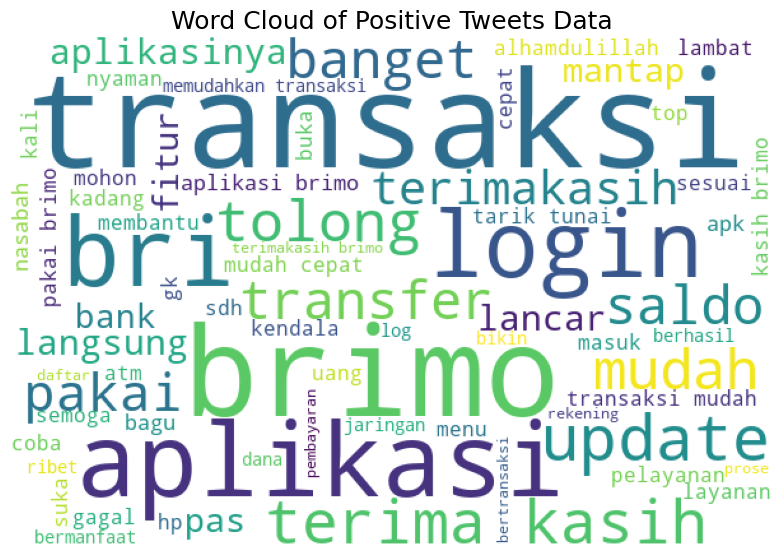

In [26]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in positive_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

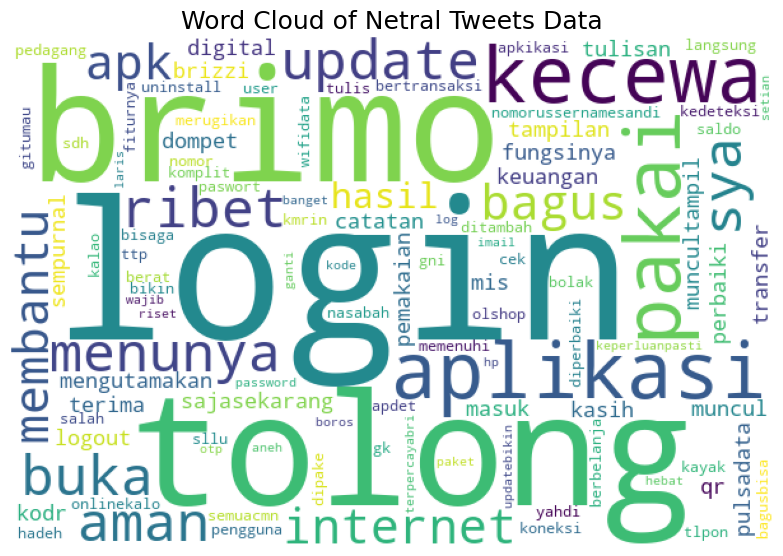

In [27]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in netral_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Netral Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

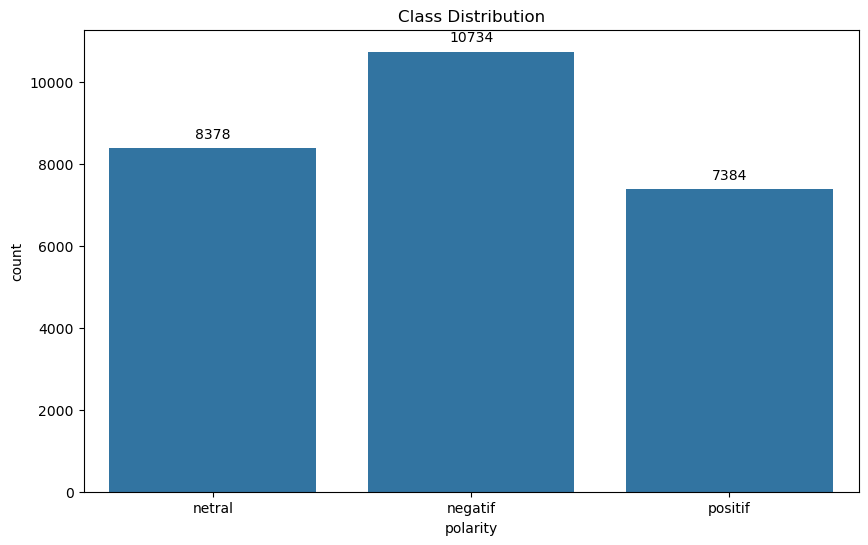

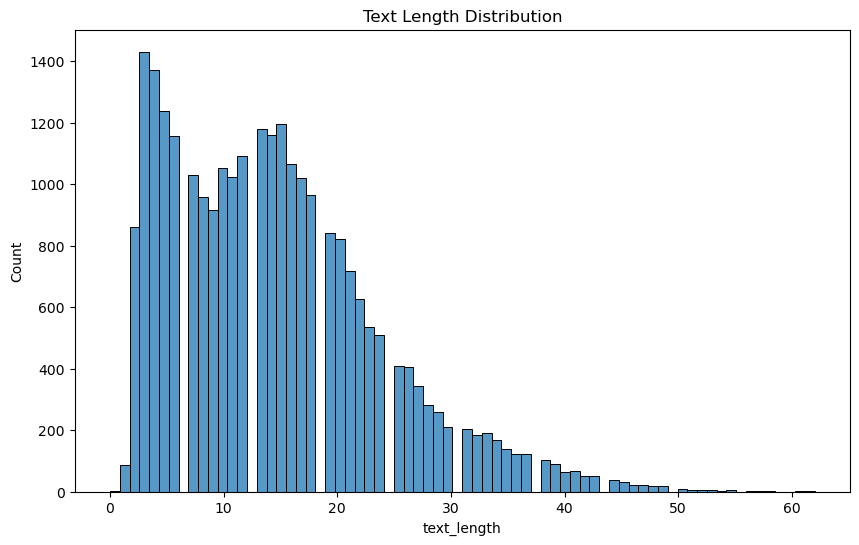

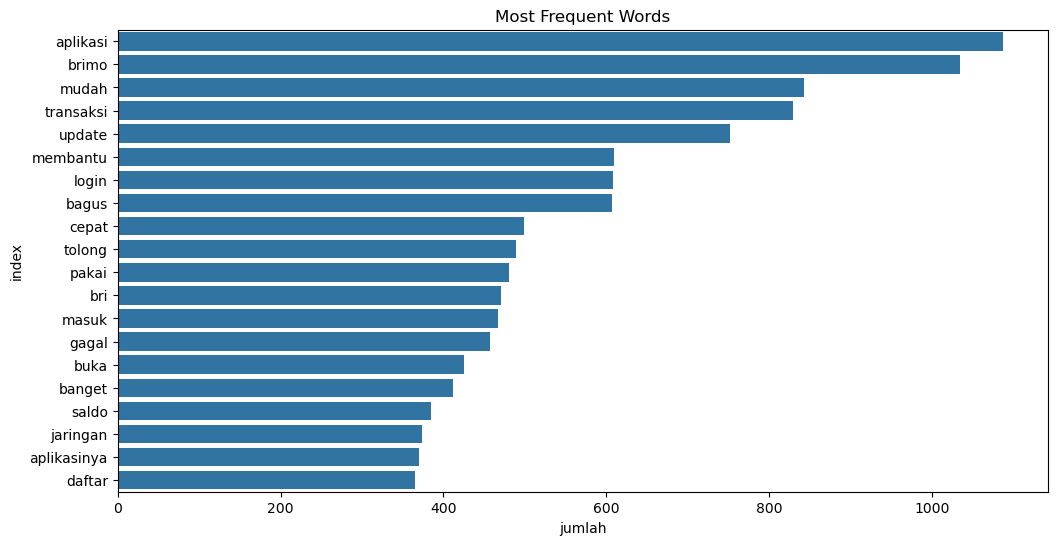

In [28]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [29]:
clean_df = clean_df.reset_index(drop=True)

In [30]:
clean_df

,content,score,thumbsUpCount,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,"Hasil Update hanya mengutamakan tampilan saja fungsinya sama saja..sekarang malah lebih ribet dan tidak aman mis: begitu buka aplikasi dan belum Login menunya sudah muncul (transfer, pulsa/data, dompet digital, Kodr QR, BRIZZI, catatan keuangan) ini sangat TIDAK AMAN menurut saya, yg seharusnya Login dulu baru menunya Muncul/tampil. Trims",1,7,Hasil Update hanya mengutamakan tampilan saja fungsinya sama sajasekarang malah lebih ribet dan tidak aman mis begitu buka aplikasi dan belum Login menunya sudah muncul transfer pulsadata dompet digital Kodr QR BRIZZI catatan keuangan ini sangat TIDAK AMAN menurut saya yg seharusnya Login dulu baru menunya Muncultampil Trims,hasil update hanya mengutamakan tampilan saja fungsinya sama sajasekarang malah lebih ribet dan tidak aman mis begitu buka aplikasi dan belum login menunya sudah muncul transfer pulsadata dompet digital kodr qr brizzi catatan keuangan ini sangat tidak aman menurut saya yg seharusnya login dulu baru menunya muncultampil trims,hasil update hanya mengutamakan tampilan saja fungsinya sama sajasekarang bahkan lebih ribet dan tidak aman mis begitu buka aplikasi dan belum login menunya sudah muncul transfer pulsadata dompet digital kodr qr brizzi catatan keuangan ini sangat tidak aman menurut saya yang seharusnya login dulu baru menunya muncultampil terima kasih,"[hasil, update, hanya, mengutamakan, tampilan, saja, fungsinya, sama, sajasekarang, bahkan, lebih, ribet, dan, tidak, aman, mis, begitu, buka, aplikasi, dan, belum, login, menunya, sudah, muncul, transfer, pulsadata, dompet, digital, kodr, qr, brizzi, catatan, keuangan, ini, sangat, tidak, aman, menurut, saya, yang, seharusnya, login, dulu, baru, menunya, muncultampil, terima, kasih]","[hasil, update, mengutamakan, tampilan, fungsinya, sajasekarang, ribet, aman, mis, buka, aplikasi, login, menunya, muncul, transfer, pulsadata, dompet, digital, kodr, qr, brizzi, catatan, keuangan, aman, login, menunya, muncultampil, terima, kasih]",hasil update mengutamakan tampilan fungsinya sajasekarang ribet aman mis buka aplikasi login menunya muncul transfer pulsadata dompet digital kodr qr brizzi catatan keuangan aman login menunya muncultampil terima kasih,-3,netral,29
1,setelah update terakhir selalu muncul notifikasi jaringan buruk baik menggunakan jaringan seluler maupun menggunakan wifi jadi setiap kali transfer harus nunggu loading dulu sampe bar berubah hijau bahkan seringkali bar tidak berubah tetap merah mohon team developer untuk memperbaiki nya,2,24,setelah update terakhir selalu muncul notifikasi jaringan buruk baik menggunakan jaringan seluler maupun menggunakan wifi jadi setiap kali transfer harus nunggu loading dulu sampe bar berubah hijau bahkan seringkali bar tidak berubah tetap merah mohon team developer untuk memperbaiki nya,setelah update terakhir selalu muncul notifikasi jaringan buruk baik menggunakan jaringan seluler maupun menggunakan wifi jadi setiap kali transfer harus nunggu loading dulu sampe bar berubah hijau bahkan seringkali bar tidak berubah tetap merah mohon team developer untuk memperbaiki nya,setelah update terakhir selalu muncul notifikasi jaringan buruk baik menggunakan jaringan seluler maupun menggunakan wifi jadi setiap kali transfer harus nunggu loading dulu sampai bar berubah hijau bahkan seringkali bar tidak berubah tetap merah mohon team developer untuk memperbaiki nya,"[setelah, update, terakhir, selalu, muncul, notifikasi, jaringan, buruk, baik, menggunakan, jaringan, seluler, maupun, menggunakan, wifi, jadi, setiap, kali, transfer, harus, nunggu, loading, dulu, sampai, bar, berubah, hijau, bahkan, seringkali, bar, tidak, berubah, tetap, merah, mohon, team, developer, untuk, memperbaiki, nya]","[update, muncul, notifikasi, jaringan, buruk, jaringan, seluler, wifi, kali, transfer, nunggu, loading, bar, berubah, hijau, seringk

# Data Splitting dan Ekstraksi Fitur

In [31]:
X = clean_df['text_akhir']
y = clean_df['polarity']

le = LabelEncoder()
y = le.fit_transform(y)

In [32]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

In [33]:
tfidf = TfidfVectorizer()
bow = CountVectorizer()
w2v = Word2Vec

In [34]:
# tf-idf
X_train_80_tfidf = tfidf.fit_transform(X_train_80)
X_test_80_tfidf = tfidf.transform(X_test_80)

X_train_70_tfidf = tfidf.fit_transform(X_train_70)
X_test_70_tfidf = tfidf.transform(X_test_70)

# bow
X_train_80_bow = bow.fit_transform(X_train_80)
X_test_80_bow = bow.transform(X_test_80)

X_train_70_bow = bow.fit_transform(X_train_70)
X_test_70_bow = bow.transform(X_test_70)

In [35]:
# w2vec
vector_size = 300
sentences = clean_df['text_stopword'].tolist()
w2v_model = w2v(sentences, vector_size=vector_size, window=7, min_count=1, sg=1, epochs=30)

def get_average_word2vec(tokens, model, k=vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(k)

X_w2vec = np.array([get_average_word2vec(tokens, w2v_model, k=vector_size) for tokens in sentences])
y_w2vec = clean_df['polarity']


y_w2vec_encoded = le.fit_transform(y_w2vec)


In [36]:
X_train_80_w2vec, X_test_80_w2vec, y_train_80_w2vec, y_test_80_w2vec = train_test_split(X_w2vec, y_w2vec_encoded, test_size=0.2, random_state=42)
X_train_70_w2vec, X_test_70_w2vec, y_train_70_w2vec, y_test_70_w2vec = train_test_split(X_w2vec, y_w2vec_encoded, test_size=0.3, random_state=42)

# Modeling

## Logistic Reg, SVM, Naive Bayes, XGBoost

In [37]:
# Logistic Reg - TF IDF
lr = LogisticRegression(max_iter=1000, C=5, multi_class='multinomial', solver='saga')
lr_tfidf = lr.fit(X_train_80_tfidf, y_train_80)

lr_tfidf_train = lr_tfidf.predict(X_train_80_tfidf)
lr_tfidf_test = lr_tfidf.predict(X_test_80_tfidf)

lr_tfidf_train_acc_80 = accuracy_score(y_train_80, lr_tfidf_train)
lr_tfidf_test_acc_80 = accuracy_score(y_test_80, lr_tfidf_test)

print(f'Train Accuracy Logistic Regression-TF IDF: {lr_tfidf_train_acc_80}')
print(f'Test Accuracy Logistic Regression-TF IDF: {lr_tfidf_test_acc_80}')

print("\n")
# Logistic Reg - BOW

lr_bow = lr.fit(X_train_80_bow, y_train_80)

lr_bow_train = lr_bow.predict(X_train_80_bow)
lr_bow_test = lr_bow.predict(X_test_80_bow)

lr_bow_train_acc_80 = accuracy_score(y_train_80, lr_bow_train)
lr_bow_test_acc_80 = accuracy_score(y_test_80, lr_bow_test)

print(f'Train Accuracy Logistic Regression-BOW: {lr_bow_train_acc_80}')
print(f'Test Accuracy Logistic Regression-BOW: {lr_bow_test_acc_80}')

print("\n")

# Logistic Reg - W2VEC
lr_w2vec = lr.fit(X_train_80_w2vec, y_train_80_w2vec)

lr_w2vec_train = lr_w2vec.predict(X_train_80_w2vec)
lr_w2vec_test = lr_w2vec.predict(X_test_80_w2vec)

lr_w2vec_train_acc_80 = accuracy_score(y_train_80_w2vec, lr_w2vec_train)
lr_w2vec_test_acc_80 = accuracy_score(y_test_80_w2vec, lr_w2vec_test)

print(f'Train Accuracy Logistic Regression-W2VEC: {lr_w2vec_train_acc_80}')
print(f'Test Accuracy Logistic Regression-W2VEC: {lr_w2vec_test_acc_80}')



c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-TF IDF: 0.9759388563879977
Test Accuracy Logistic Regression-TF IDF: 0.829622641509434




c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-BOW: 0.9973579920739762
Test Accuracy Logistic Regression-BOW: 0.8805660377358491




c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-W2VEC: 0.7436780524627288
Test Accuracy Logistic Regression-W2VEC: 0.7111320754716981


In [38]:
# Logistic Reg - TF IDF
lr_tfidf = lr.fit(X_train_70_tfidf, y_train_70)

lr_tfidf_train = lr_tfidf.predict(X_train_70_tfidf)
lr_tfidf_test = lr_tfidf.predict(X_test_70_tfidf)

lr_tfidf_train_acc_70 = accuracy_score(y_train_70, lr_tfidf_train)
lr_tfidf_test_acc_70 = accuracy_score(y_test_70, lr_tfidf_test)

print(f'Train Accuracy Logistic Regression-TF IDF: {lr_tfidf_train_acc_70}')
print(f'Test Accuracy Logistic Regression-TF IDF: {lr_tfidf_test_acc_70}')

print("\n")
# Logistic Reg - BOW

lr_bow = lr.fit(X_train_70_bow, y_train_70)

lr_bow_train = lr_bow.predict(X_train_70_bow)
lr_bow_test = lr_bow.predict(X_test_70_bow)

lr_bow_train_acc_70 = accuracy_score(y_train_70, lr_bow_train)
lr_bow_test_acc_70 = accuracy_score(y_test_70, lr_bow_test)

print(f'Train Accuracy Logistic Regression-BOW: {lr_bow_train_acc_70}')
print(f'Test Accuracy Logistic Regression-BOW: {lr_bow_test_acc_70}')

print("\n")

# Logistic Reg - W2VEC
lr_w2vec = lr.fit(X_train_70_w2vec, y_train_70_w2vec)

lr_w2vec_train = lr_w2vec.predict(X_train_70_w2vec)
lr_w2vec_test = lr_w2vec.predict(X_test_70_w2vec)

lr_w2vec_train_acc_70 = accuracy_score(y_train_70_w2vec, lr_w2vec_train)
lr_w2vec_test_acc_70 = accuracy_score(y_test_70_w2vec, lr_w2vec_test)

print(f'Train Accuracy Logistic Regression-W2VEC: {lr_w2vec_train_acc_70}')
print(f'Test Accuracy Logistic Regression-W2VEC: {lr_w2vec_test_acc_70}')

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-TF IDF: 0.9764382379899714
Test Accuracy Logistic Regression-TF IDF: 0.830167316643603




c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-BOW: 0.9974119803741845
Test Accuracy Logistic Regression-BOW: 0.8777204679833941




c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Train Accuracy Logistic Regression-W2VEC: 0.7467514961988462
Test Accuracy Logistic Regression-W2VEC: 0.7130456661215248


In [39]:
# Naive-Bayes - TF IDF
nb = MultinomialNB()
nb_tfidf = nb.fit(X_train_80_tfidf, y_train_80)

nb_tfidf_train = nb_tfidf.predict(X_train_80_tfidf)
nb_tfidf_test = nb_tfidf.predict(X_test_80_tfidf)

nb_tfidf_train_acc_80 = accuracy_score(y_train_80, nb_tfidf_train)
nb_tfidf_test_acc_80 = accuracy_score(y_test_80, nb_tfidf_test)

print(f'Train Accuracy Naive Bayes-TF IDF: {nb_tfidf_train_acc_80}')
print(f'Test Accuracy Naive Bayes-TF IDF: {nb_tfidf_test_acc_80}')

print("\n")

# Naive-Bayes - BOW
nb_bow = nb.fit(X_train_80_bow, y_train_80)

nb_bow_train = nb_bow.predict(X_train_80_bow)
nb_bow_test = nb_bow.predict(X_test_80_bow)

nb_bow_train_acc_80 = accuracy_score(y_train_80, nb_bow_train)
nb_bow_test_acc_80 = accuracy_score(y_test_80, nb_bow_test)

print(f'Train Accuracy Naive Bayes-BOW: {nb_bow_train_acc_80}')
print(f'Test Accuracy Naive Bayes-BOW: {nb_bow_test_acc_80}')

Train Accuracy Naive Bayes-TF IDF: 0.7038120400075486
Test Accuracy Naive Bayes-TF IDF: 0.5845283018867925


Train Accuracy Naive Bayes-BOW: 0.7679750896395546
Test Accuracy Naive Bayes-BOW: 0.6194339622641509


In [40]:
# Naive-Bayes - TF IDF
nb = MultinomialNB()
nb_tfidf = nb.fit(X_train_70_tfidf, y_train_70)

nb_tfidf_train = nb_tfidf.predict(X_train_70_tfidf)
nb_tfidf_test = nb_tfidf.predict(X_test_70_tfidf)

nb_tfidf_train_acc_70 = accuracy_score(y_train_70, nb_tfidf_train)
nb_tfidf_test_acc_70 = accuracy_score(y_test_70, nb_tfidf_test)

print(f'Train Accuracy Naive Bayes-TF IDF: {nb_tfidf_train_acc_70}')
print(f'Test Accuracy Naive Bayes-TF IDF: {nb_tfidf_test_acc_70}')

print("\n")

# Naive-Bayes - BOW
nb_bow = nb.fit(X_train_70_bow, y_train_70)

nb_bow_train = nb_bow.predict(X_train_70_bow)
nb_bow_test = nb_bow.predict(X_test_70_bow)

nb_bow_train_acc_70 = accuracy_score(y_train_70, nb_bow_train)
nb_bow_test_acc_70 = accuracy_score(y_test_70, nb_bow_test)

print(f'Train Accuracy Naive Bayes-BOW: {nb_bow_train_acc_70}')
print(f'Test Accuracy Naive Bayes-BOW: {nb_bow_test_acc_70}')

Train Accuracy Naive Bayes-TF IDF: 0.7050196797325713
Test Accuracy Naive Bayes-TF IDF: 0.5783117373254497


Train Accuracy Naive Bayes-BOW: 0.7719846875505473
Test Accuracy Naive Bayes-BOW: 0.6165555415775569


In [41]:
# SVM - TF IDF
svm = SVC()
svm_tfidf = svm.fit(X_train_80_tfidf, y_train_80)

svm_tfidf_train = svm_tfidf.predict(X_train_80_tfidf)
svm_tfidf_test = svm_tfidf.predict(X_test_80_tfidf)

svm_tfidf_train_acc_80 = accuracy_score(y_train_80, svm_tfidf_train)
svm_tfidf_test_acc_80 = accuracy_score(y_test_80, svm_tfidf_test)

print(f'Train Accuracy SVM-TF IDF: {svm_tfidf_train_acc_80}')
print(f'Test Accuracy SVM-TF IDF: {svm_tfidf_test_acc_80}')

print("\n")

# SVM - BOW
svm_bow = svm.fit(X_train_80_bow, y_train_80)

svm_bow_train = svm_bow.predict(X_train_80_bow)
svm_bow_test = svm_bow.predict(X_test_80_bow)

svm_bow_train_acc_80 = accuracy_score(y_train_80, svm_bow_train)
svm_bow_test_acc_80 = accuracy_score(y_test_80, svm_bow_test)

print(f'Train Accuracy SVM-BOW: {svm_bow_train_acc_80}')
print(f'Test Accuracy SVM-BOW: {svm_bow_test_acc_80}')

print("\n")

# SVM - WORD2VEC
svm_w2vec = svm.fit(X_train_80_w2vec, y_train_80_w2vec)

svm_w2vec_train = svm_w2vec.predict(X_train_80_w2vec)
svm_w2vec_test = svm_w2vec.predict(X_test_80_w2vec)

svm_w2vec_train_acc_80 = accuracy_score(y_train_80_w2vec, svm_w2vec_train)
svm_w2vec_test_acc_80 = accuracy_score(y_test_80_w2vec, svm_w2vec_test)

print(f'Train Accuracy SVM-W2VEC: {svm_w2vec_train_acc_80}')
print(f'Test Accuracy SVM-W2VEC: {svm_w2vec_test_acc_80}')

Train Accuracy SVM-TF IDF: 0.9926872994904699
Test Accuracy SVM-TF IDF: 0.8226415094339623


Train Accuracy SVM-BOW: 0.9585299113040197
Test Accuracy SVM-BOW: 0.8088679245283019


Train Accuracy SVM-W2VEC: 0.81840913379883
Test Accuracy SVM-W2VEC: 0.7420754716981132


In [42]:
# SVM - TF IDF
svm = SVC()
svm_tfidf = svm.fit(X_train_70_tfidf, y_train_70)

svm_tfidf_train = svm_tfidf.predict(X_train_70_tfidf)
svm_tfidf_test = svm_tfidf.predict(X_test_70_tfidf)

svm_tfidf_train_acc_70 = accuracy_score(y_train_70, svm_tfidf_train)
svm_tfidf_test_acc_70 = accuracy_score(y_test_70, svm_tfidf_test)

print(f'Train Accuracy SVM-TF IDF: {svm_tfidf_train_acc_70}')
print(f'Test Accuracy SVM-TF IDF: {svm_tfidf_test_acc_70}')

print("\n")

# SVM - BOW
svm_bow = svm.fit(X_train_70_bow, y_train_70)

svm_bow_train = svm_bow.predict(X_train_70_bow)
svm_bow_test = svm_bow.predict(X_test_70_bow)

svm_bow_train_acc_70 = accuracy_score(y_train_70, svm_bow_train)
svm_bow_test_acc_70 = accuracy_score(y_test_70, svm_bow_test)

print(f'Train Accuracy SVM-BOW: {svm_bow_train_acc_70}')
print(f'Test Accuracy SVM-BOW: {svm_bow_test_acc_70}')

print("\n")

# SVM - WORD2VEC
svm_w2vec = svm.fit(X_train_70_w2vec, y_train_70_w2vec)

svm_w2vec_train = svm_w2vec.predict(X_train_70_w2vec)
svm_w2vec_test = svm_w2vec.predict(X_test_70_w2vec)

svm_w2vec_train_acc_70 = accuracy_score(y_train_70_w2vec, svm_w2vec_train)
svm_w2vec_test_acc_70 = accuracy_score(y_test_70_w2vec, svm_w2vec_test)

print(f'Train Accuracy SVM-W2VEC: {svm_w2vec_train_acc_70}')
print(f'Test Accuracy SVM-W2VEC: {svm_w2vec_test_acc_70}')

Train Accuracy SVM-TF IDF: 0.9921820240470157
Test Accuracy SVM-TF IDF: 0.8135614542709775


Train Accuracy SVM-BOW: 0.9581064323071117
Test Accuracy SVM-BOW: 0.8055101270600076


Train Accuracy SVM-W2VEC: 0.8168976114735537
Test Accuracy SVM-W2VEC: 0.7413511133475909


In [43]:
xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

In [44]:
# xgboost - tf idf

xgb_tfidf = xgb.fit(X_train_80_tfidf, y_train_80)

xgb_tfidf_train = xgb_tfidf.predict(X_train_80_tfidf)
xgb_tfidf_test = xgb_tfidf.predict(X_test_80_tfidf)

xgb_tfidf_train_acc = accuracy_score(y_train_80, xgb_tfidf_train)
xgb_tfidf_test_acc = accuracy_score(y_test_80, xgb_tfidf_test)

print(f'Train Accuracy XGBoost-TF IDF: {xgb_tfidf_train_acc}')
print(f'Test Accuracy XGBoost-TF IDF: {xgb_tfidf_test_acc}')

print("\n")

# xgboost - bow
xgb_bow = xgb.fit(X_train_80_bow, y_train_80)

xgb_bow_train = xgb_bow.predict(X_train_80_bow)
xgb_bow_test = xgb_bow.predict(X_test_80_bow)

xgb_bow_train_acc = accuracy_score(y_train_80, xgb_bow_train)
xgb_bow_test_acc = accuracy_score(y_test_80, xgb_bow_test)

print(f'Train Accuracy XGBoost-BOW: {xgb_bow_train_acc}')
print(f'Test Accuracy XGBoost-BOW: {xgb_bow_test_acc}')

print("\n")

# xgboost - w2v
xgb_w2vec = xgb.fit(X_train_80_w2vec, y_train_80_w2vec)

xgb_w2vec_train = xgb_w2vec.predict(X_train_80_w2vec)
xgb_w2vec_test = xgb_w2vec.predict(X_test_80_w2vec)

xgb_w2vec_train_acc = accuracy_score(y_train_80_w2vec, xgb_w2vec_train)
xgb_w2vec_test_acc = accuracy_score(y_test_80_w2vec, xgb_w2vec_test)

print(f'Train Accuracy XGBoost-W2VEC: {xgb_w2vec_train_acc}')
print(f'Test Accuracy XGBoost-W2VEC: {xgb_w2vec_test_acc}')


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:44:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-TF IDF: 0.8835157576901302
Test Accuracy XGBoost-TF IDF: 0.7541509433962265




c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:44:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-BOW: 0.8553972447631628
Test Accuracy XGBoost-BOW: 0.7556603773584906




c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:45:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-W2VEC: 0.9983015663332704
Test Accuracy XGBoost-W2VEC: 0.6811320754716981


In [45]:
# xgboost - tf idf

xgb_tfidf = xgb.fit(X_train_70_tfidf, y_train_70)

xgb_tfidf_train = xgb_tfidf.predict(X_train_70_tfidf)
xgb_tfidf_test = xgb_tfidf.predict(X_test_70_tfidf)

xgb_tfidf_train_acc = accuracy_score(y_train_70, xgb_tfidf_train)
xgb_tfidf_test_acc = accuracy_score(y_test_70, xgb_tfidf_test)

print(f'Train Accuracy XGBoost-TF IDF: {xgb_tfidf_train_acc}')
print(f'Test Accuracy XGBoost-TF IDF: {xgb_tfidf_test_acc}')

print("\n")

# xgboost - bow
xgb_bow = xgb.fit(X_train_70_bow, y_train_70)

xgb_bow_train = xgb_bow.predict(X_train_70_bow)
xgb_bow_test = xgb_bow.predict(X_test_70_bow)

xgb_bow_train_acc = accuracy_score(y_train_70, xgb_bow_train)
xgb_bow_test_acc = accuracy_score(y_test_70, xgb_bow_test)

print(f'Train Accuracy XGBoost-BOW: {xgb_bow_train_acc}')
print(f'Test Accuracy XGBoost-BOW: {xgb_bow_test_acc}')

print("\n")

# xgboost - w2v
xgb_w2vec = xgb.fit(X_train_70_w2vec, y_train_70_w2vec)

xgb_w2vec_train = xgb_w2vec.predict(X_train_70_w2vec)
xgb_w2vec_test = xgb_w2vec.predict(X_test_70_w2vec)

xgb_w2vec_train_acc = accuracy_score(y_train_70_w2vec, xgb_w2vec_train)
xgb_w2vec_test_acc = accuracy_score(y_test_70_w2vec, xgb_w2vec_test)

print(f'Train Accuracy XGBoost-W2VEC: {xgb_w2vec_train_acc}')
print(f'Test Accuracy XGBoost-W2VEC: {xgb_w2vec_test_acc}')


c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:45:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-TF IDF: 0.890440502507144
Test Accuracy XGBoost-TF IDF: 0.7553151339791169




c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-BOW: 0.8629967110583922
Test Accuracy XGBoost-BOW: 0.7588375896339162




c:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy XGBoost-W2VEC: 0.9991373267913949
Test Accuracy XGBoost-W2VEC: 0.6824757831173732


**Insight:**
- Metode TF-IDF dan BOW menunjukkan hasil yang lebih baik daripada Word2Vec. Untuk Word2Vec telah dicoba beberapa parameter namun tidak memberikan perbedaan.
- Model dengan Logistic Regression memberikan hasil yang baik, dilanjutkan dengan SVM, Naive Bayes, lalu xgboost. Namun, untuk Logistic Regression dan SVM akan lebih dipertimbangkan daripada dua model yang lain.
- Penggunaan test size sebesar 0.2 dan 0.3 tidak memberikan perbedaan yang signifikan.
- Bisa ditingkatkan lagi dengan hyperparameter tuning (sudah dicoba untuk Grid Search namun hanya memberikan hasil yang tidak jauh beda, accuracy sekitar 88%. Di sini sudah dihapus untuk sntax nya karena terlalu lama buat run, sekitar 3 jam)

In [46]:
# dataframe accuracy train dan test LR SVM
accuracy_summary_df = pd.DataFrame(columns=['Model-Ekstrak Fitur', 'Train Accuracy-80', 'Test Accuracy-80', 'Train Accuracy-70', 'Test Accuracy-70'])

accuracy_summary_df = pd.concat([accuracy_summary_df,
    pd.DataFrame([{'Model-Ekstrak Fitur': 'LR-TF IDF',
     'Train Accuracy-80': lr_tfidf_train_acc_80,
     'Test Accuracy-80': lr_tfidf_test_acc_80,
      'Train Accuracy-70': lr_tfidf_train_acc_70,
     'Test Accuracy-70': lr_tfidf_test_acc_70}])], ignore_index=True)
accuracy_summary_df = pd.concat([accuracy_summary_df,
    pd.DataFrame([{'Model-Ekstrak Fitur': 'LR-BOW',
     'Train Accuracy-80': lr_bow_train_acc_80,
     'Test Accuracy-80': lr_bow_test_acc_80,
    'Train Accuracy-70': lr_bow_train_acc_70,
     'Test Accuracy-70': lr_bow_test_acc_70}])], ignore_index=True)

accuracy_summary_df = pd.concat([accuracy_summary_df,
    pd.DataFrame([{'Model-Ekstrak Fitur': 'SVM-BOW',
     'Train Accuracy-80': svm_bow_train_acc_80,
     'Test Accuracy-80': svm_bow_test_acc_80,
    'Train Accuracy-70': svm_bow_train_acc_70,
     'Test Accuracy-70': svm_bow_test_acc_70}])], ignore_index=True)
accuracy_summary_df = pd.concat([accuracy_summary_df,
    pd.DataFrame([{'Model-Ekstrak Fitur': 'SVM-TF IDF',
     'Train Accuracy-80': svm_tfidf_train_acc_80,
     'Test Accuracy-80': svm_tfidf_test_acc_80,
    'Train Accuracy-70': svm_bow_train_acc_70,
     'Test Accuracy-70': svm_bow_test_acc_70}])], ignore_index=True)

accuracy_summary_df

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_54344\1824002237.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  accuracy_summary_df = pd.concat([accuracy_summary_df,


,Model-Ekstrak Fitur,Train Accuracy-80,Test Accuracy-80,Train Accuracy-70,Test Accuracy-70
0,LR-TF IDF,0.975939,0.829623,0.976438,0.830167
1,LR-BOW,0.997358,0.880566,0.997412,0.877720
2,SVM-BOW,0.958530,0.808868,0.958106,0.805510
3,SVM-TF IDF,0.992687,0.822642,0.958106,0.805510


## Voting

Performa terbaik dicapai oleh Logictic Regression - BOW. Untuk SVM - TD IDF sangat overvitting. Akan dicoba dengan voting.

In [47]:
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42))
    ],
    voting='soft'
)

voting.fit(X_train_80_bow, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_bow, y_test_80))


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.8886792452830189


In [48]:
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42))
    ],
    voting='soft'
)

voting.fit(X_train_80_tfidf, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_tfidf, y_test_80))


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.8509433962264151


In [49]:
voting = VotingClassifier(
    estimators=[
          ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42)),
        ('nb', MultinomialNB())
    ],
    voting='soft'
)
voting.fit(X_train_80_bow, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_bow, y_test_80))

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.8749056603773585


In [50]:
voting = VotingClassifier(
    estimators=[
          ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42)),
        ('nb', MultinomialNB())
    ],
    voting='soft'
)
voting.fit(X_train_80_tfidf, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_tfidf, y_test_80))

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.8432075471698113


In [51]:
voting = VotingClassifier(
    estimators=[
           ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42)),
        ('nb', MultinomialNB())
    ],
    voting='hard'
)
voting.fit(X_train_80_bow, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_bow, y_test_80))

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.88


In [52]:
voting = VotingClassifier(
    estimators=[ 
           ('lr', LogisticRegression(
             C=10,
            solver='saga',
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )),
        ('svm', SVC(
              C=5,
            kernel='linear',
            probability=True,
            random_state=42)),
        ('nb', MultinomialNB())
    ],
    voting='hard'
)

voting.fit(X_train_80_tfidf, y_train_80)
print("Voting Test Accuracy:", voting.score(X_test_80_tfidf, y_test_80))

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Voting Test Accuracy: 0.8318867924528301


Akurasi tertinggi diperoleh percobaan pertama. Dengan BOW memiliki akurasi lebih tinggi daripada menggunakan TF-IDF.

## Deep Learning

Akan dicoba dengan Deep Learning.

### TF-IDF

In [53]:
X_tfidf = tfidf.fit_transform(X)

In [54]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [55]:
model = Sequential([
    Dense(512, input_shape=(X_train_tfidf.shape[1],),
    activation='relu',
    #kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = tensorflow.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
    )
history = model.fit(
    X_train_tfidf.toarray(), y_train_tfidf,
    validation_data=(X_test_tfidf.toarray(), y_test_tfidf),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.4092 - loss: 1.0783 - val_accuracy: 0.5700 - val_loss: 0.9182
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.6486 - loss: 0.8064 - val_accuracy: 0.7723 - val_loss: 0.5824
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.8457 - loss: 0.4801 - val_accuracy: 0.8249 - val_loss: 0.4346
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9157 - loss: 0.3100 - val_accuracy: 0.8445 - val_loss: 0.3684
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.9409 - loss: 0.2180 - val_accuracy: 0.8464 - val_loss: 0.3443
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - accuracy: 0.9608 - loss: 0.1587 - val_accuracy: 0.8553 - val_loss: 0.3269
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - accuracy: 0.9670 - loss: 0.1259 - val_accuracy: 0.8536 - val_loss: 0.3263
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.9737 - loss: 0

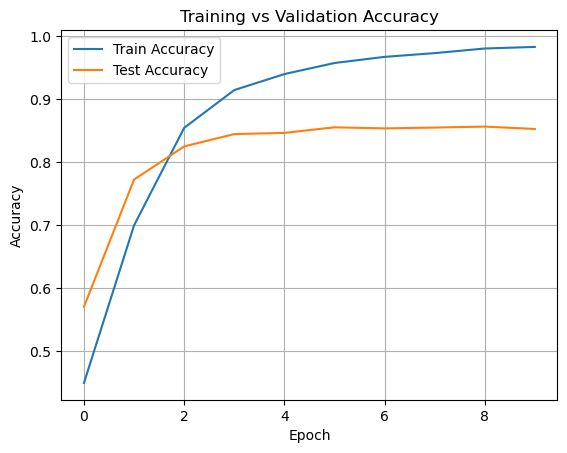

In [56]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.show()


In [57]:
model2 = Sequential([
    Dense(256, activation='relu',
          input_shape=(X_train_tfidf.shape[1],),
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.6),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)

model2.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model2.fit(
    X_train_tfidf, y_train_tfidf,
    validation_data=(X_test_tfidf, y_test_tfidf),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.4172 - loss: 1.6118 - val_accuracy: 0.4628 - val_loss: 1.3733 - learning_rate: 1.0000e-04
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6740 - loss: 1.0810 - val_accuracy: 0.7391 - val_loss: 1.1492 - learning_rate: 1.0000e-04
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.8133 - loss: 0.7723 - val_accuracy: 0.8228 - val_loss: 0.8500 - learning_rate: 1.0000e-04
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.8937 - loss: 0.5903 - val_accuracy: 0.8411 - val_loss: 0.6712 - learning_rate: 1.0000e-04
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9250 - loss: 0.4998 - val_accuracy: 0.8525 - val_loss: 0.6153 - learning_rate: 1.0000e-04
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.9406 - loss: 0.4451 - val_accuracy: 0.8500 - val_loss: 0.6080 - learning_rate: 1.0000e-04
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/ste

In [58]:
model3 = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train_tfidf.shape[1],),
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)

model3.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model3.fit(
    X_train_tfidf, y_train_tfidf,
    validation_data=(X_test_tfidf, y_test_tfidf),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.4341 - loss: 1.3334 - val_accuracy: 0.5153 - val_loss: 1.2229 - learning_rate: 1.0000e-04
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6213 - loss: 0.9960 - val_accuracy: 0.7298 - val_loss: 1.0614 - learning_rate: 1.0000e-04
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7420 - loss: 0.7606 - val_accuracy: 0.8087 - val_loss: 0.8074 - learning_rate: 1.0000e-04
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8466 - loss: 0.5796 - val_accuracy: 0.8308 - val_loss: 0.6004 - learning_rate: 1.0000e-04
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8963 - loss: 0.4592 - val_accuracy: 0.8368 - val_loss: 0.5266 - learning_rate: 1.0000e-04
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9259 - loss: 0.3789 - val_accuracy: 0.8442 - val_loss: 0.5057 - learning_rate: 1.0000e-04
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc

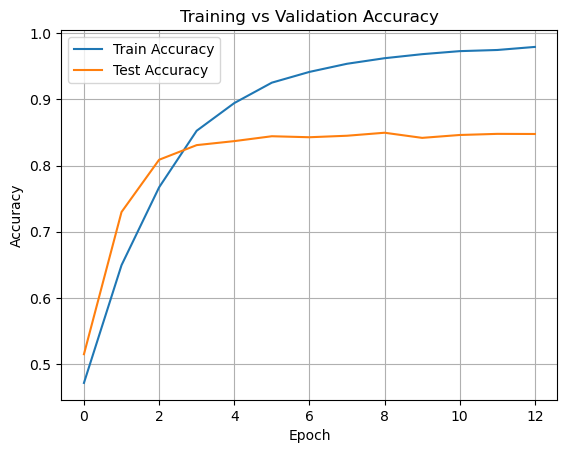

In [59]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.show()


In [60]:
tfidf_10000 = TfidfVectorizer(max_features=20000)
X_train_tfidf_10k = tfidf_10000.fit_transform(X_train_80)
X_test_tfidf_10k = tfidf_10000.transform(X_test_80)

In [61]:
modelK = Sequential([
    Dense(512, input_shape=(X_train_tfidf_10k.shape[1],),
    activation='relu',
    kernel_regularizer=tensorflow.keras.regularizers.l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)

modelK.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#model4.fit(X_bow, y, epochs=10, batch_size=64, validation_split=0.2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = modelK.fit(
    X_train_tfidf_10k, y_train_tfidf,
    validation_data=(X_test_tfidf_10k, y_test_tfidf),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.4712 - loss: 1.6319 - val_accuracy: 0.5104 - val_loss: 1.2289 - learning_rate: 1.0000e-04
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.7800 - loss: 0.7546 - val_accuracy: 0.7489 - val_loss: 0.9668 - learning_rate: 1.0000e-04
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.8948 - loss: 0.4876 - val_accuracy: 0.8326 - val_loss: 0.6813 - learning_rate: 1.0000e-04
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.9379 - loss: 0.3605 - val_accuracy: 0.8434 - val_loss: 0.5214 - learning_rate: 1.0000e-04
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9631 - loss: 0.2806 - val_accuracy: 0.8564 - val_loss: 0.4688 - learning_rate: 1.0000e-04
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.9749 - loss: 0.2320 - val_accuracy: 0.8504 - val_loss: 0.4723 - learning_rate: 1.0000e-04
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 113

### BOW

In [62]:
X_bow = bow.fit_transform(X)


In [63]:
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(X_bow, y, test_size=0.2, random_state=42)

In [64]:
model4 = Sequential([
    Dense(512, input_shape=(X_train_bow.shape[1],),
    activation='relu',
    #kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)

model4.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#model4.fit(X_bow, y, epochs=10, batch_size=64, validation_split=0.2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model4.fit(
    X_train_bow.toarray(), y_train_bow,
    validation_data=(X_test_bow.toarray(), y_test_bow),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - accuracy: 0.4247 - loss: 1.0478 - val_accuracy: 0.6523 - val_loss: 0.8027 - learning_rate: 1.0000e-04
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.7315 - loss: 0.6923 - val_accuracy: 0.8155 - val_loss: 0.4910 - learning_rate: 1.0000e-04
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 149ms/step - accuracy: 0.8703 - loss: 0.4018 - val_accuracy: 0.8604 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.9255 - loss: 0.2619 - val_accuracy: 0.8796 - val_loss: 0.3185 - learning_rate: 1.0000e-04
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.9513 - loss: 0.1776 - val_accuracy: 0.8874 - val_loss: 0.2886 - learning_rate: 1.0000e-04
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.9676 - loss: 0.1269 - val_accuracy: 0.8923 - val_loss: 0.2755 - learning_rate: 1.0000e-04
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 10

In [65]:
model5 = Sequential([
    Dense(1024, activation='relu',
           input_shape=(X_train_bow.shape[1],), 
           kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  
])
optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-4)

model5.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model5.fit(
    X_train_bow.toarray(), y_train_bow,
    validation_data=(X_test_bow.toarray(), y_test_bow),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 100s 281ms/step - accuracy: 0.4805 - loss: 2.2810 - val_accuracy: 0.8260 - val_loss: 0.9139 - learning_rate: 1.0000e-04
Epoch 2/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 64s 192ms/step - accuracy: 0.8693 - loss: 0.8038 - val_accuracy: 0.8819 - val_loss: 0.6628 - learning_rate: 1.0000e-04
Epoch 3/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 72s 217ms/step - accuracy: 0.9345 - loss: 0.5346 - val_accuracy: 0.8985 - val_loss: 0.5680 - learning_rate: 1.0000e-04
Epoch 4/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 70s 212ms/step - accuracy: 0.9618 - loss: 0.4007 - val_accuracy: 0.9011 - val_loss: 0.5213 - learning_rate: 1.0000e-04
Epoch 5/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 68s 204ms/step - accuracy: 0.9766 - loss: 0.3242 - val_accuracy: 0.9068 - val_loss: 0.4859 - learning_rate: 1.0000e-04
Epoch 6/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 74s 223ms/step - accuracy: 0.9827 - loss: 0.2749 - val_accuracy: 0.9055 - val_loss: 0.4803 - learning_rate: 1.0000e-04
Epoch 7/30
332/332 ━━━━━━━━━━━━━━━━━━━━ 70s 2

In [66]:
model6 = Sequential([
    Dense(1024, activation='relu',
           input_shape=(X_train_bow.shape[1],), 
           kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  
])
optimizer = tensorflow.keras.optimizers.Nadam(learning_rate=1e-4)

model6.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model6.fit(
    X_train_bow.toarray(), y_train_bow,
    validation_data=(X_test_bow.toarray(), y_test_bow),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 162s 233ms/step - accuracy: 0.5442 - loss: 1.9387 - val_accuracy: 0.8577 - val_loss: 0.7724 - learning_rate: 1.0000e-04
Epoch 2/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 151s 228ms/step - accuracy: 0.8897 - loss: 0.6675 - val_accuracy: 0.8870 - val_loss: 0.5882 - learning_rate: 1.0000e-04
Epoch 3/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 146s 219ms/step - accuracy: 0.9461 - loss: 0.4457 - val_accuracy: 0.8994 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 4/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 161s 243ms/step - accuracy: 0.9679 - loss: 0.3386 - val_accuracy: 0.9085 - val_loss: 0.4747 - learning_rate: 1.0000e-04
Epoch 5/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 170s 256ms/step - accuracy: 0.9745 - loss: 0.2775 - val_accuracy: 0.9025 - val_loss: 0.4620 - learning_rate: 1.0000e-04
Epoch 6/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 172s 260ms/step - accuracy: 0.9803 - loss: 0.2363 - val_accuracy: 0.8985 - val_loss: 0.4522 - learning_rate: 1.0000e-04
Epoch 7/30
663/663 ━━━━━━━━━━━━━━━━━━━━ 

### Rangkuman
- Model terbaik dengan Deep Learning ditunjukkan oleh model6 pada bagian Deep Learning di mana akurasi ~92% (bintang 5 :)) . Ekstraksi fitur dengan BOW memberikan hasil yang lebih baik daripada TF-IDF.
- Pada kombinasi Logistic Regression dan TF-IDF dengan pembagian 80/20 dan 70/30 masing-masing memberikan akurasi testing di atas 85%, namun masih di bawah 92%. Sudah dicoba dengan Grid Search dengan waktu compile cukup lama (sekitar 3 jam) tapi masih memberikan hasil sekitar 87% (di sini sudah dihapus karena waktu compile untuk running lama hehe..).
- Pada voting, model dengan Logistic Regression + VM memberikan akurasi testing terbaik diantara yang lainnya. Akurasi testing menunjukkan di atas 85%, namun di bawah 92%.

# Inference Testing

In [67]:
review = ['Aplikasinya keren banget, sudah pas untuk kebutuhan saya',
          'sudah bagus, namun terkadang ada eror saat login',
          'aplikasi jelek, aku kecewa']

review_tfidf = tfidf.transform(review)

prediction = model5.predict(review_tfidf.toarray())
prediction = np.argmax(prediction, axis=1)

label_sentimen = le.inverse_transform(prediction)
for review, sentimen in zip(review, label_sentimen):
    print(f"Review: {review} => Sentimen: {sentimen}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Review: Aplikasinya keren banget, sudah pas untuk kebutuhan saya => Sentimen: positif
Review: sudah bagus, namun terkadang ada eror saat login => Sentimen: netral
Review: aplikasi jelek, aku kecewa => Sentimen: negatif


In [78]:
review = ['Aplikasinya keren banget, sudah pas untuk kebutuhan saya',
          'sudah bagus, namun terkadang ada eror saat login',
          'aplikasi jelek, aku kecewa',
          'sangat membantu dan mudah digunakan',
          'sudah bagus, tapi perlu fitur tambahan',
          'aplikasi sangat lambat dan sering crash']

review_bow = bow.transform(review)

prediction = model6.predict(review_bow.toarray())
prediction = np.argmax(prediction, axis=1)

label_sentimen = le.inverse_transform(prediction)
for review, sentimen in zip(review, label_sentimen):
    print(f"Review: {review} => Sentimen: {sentimen}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Review: Aplikasinya keren banget, sudah pas untuk kebutuhan saya => Sentimen: positif
Review: sudah bagus, namun terkadang ada eror saat login => Sentimen: negatif
Review: aplikasi jelek, aku kecewa => Sentimen: negatif
Review: sangat membantu dan mudah digunakan => Sentimen: positif
Review: sudah bagus, tapi perlu fitur tambahan => Sentimen: netral
Review: aplikasi sangat lambat dan sering crash => Sentimen: negatif
